In [1]:
#Importación de librerías
import pyodbc
import pandas as pd
import numpy as np

In [2]:
#Conexión a SQL Server
conn = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=DESKTOP-87MLI8D\MSSQLSERVER01;"
    "DATABASE=Delitos Estatales;"
    "Trusted_Connection=yes;"
)

In [3]:
#Carga tabla original
query = "SELECT * FROM delitos_fuero_comun"
df = pd.read_sql(query, conn)

C:\Users\Nefi\AppData\Local\Temp\ipykernel_12100\692054870.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [4]:
#EDA
#TOP 20
df.head(20)

#Conteo de registros
total_registros = len(df)

#Rango de años
año_min = df['Año'].min()
año_max = df['Año'].max()

print(total_registros, año_min, año_max)

34496 2015 2025


In [5]:
#UNPIVOT equivalente en SQL con MELT
#Columnas de meses
meses = [
    'Enero','Febrero','Marzo','Abril','Mayo','Junio',
    'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre'
]

#Unpivot con melt
df_norm_py = df.melt(
    id_vars=[
        'Año','Clave_Ent','Entidad',
        'Bien_jurídico_afectado',
        'Tipo_de_delito',
        'Subtipo_de_delito',
        'Modalidad'
    ],
    value_vars=meses,
    var_name='Mes',
    value_name='Delitos'
)

df_norm_py.head()

,Año,Clave_Ent,Entidad,Bien_jurídico_afectado,Tipo_de_delito,Subtipo_de_delito,Modalidad,Mes,Delitos
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Enero,3
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Enero,1
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Enero,0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Enero,2
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,Enero,0


In [6]:
#Variables derivadas de meses
mes_map = {
    'Enero':1,'Febrero':2,'Marzo':3,'Abril':4,'Mayo':5,'Junio':6,
    'Julio':7,'Agosto':8,'Septiembre':9,'Octubre':10,'Noviembre':11,'Diciembre':12
}

df_norm_py['Mes_num'] = df_norm_py['Mes'].map(mes_map)

In [7]:
#Asiganción de Fecha
df_norm_py['Fecha'] = pd.to_datetime(
    df_norm_py['Año'].astype(str) + '-' +
    df_norm_py['Mes_num'].astype(str) + '-01'
)

In [9]:
#Formato Año-Mes
df_norm_py['AñoMes'] = df_norm_py['Fecha'].dt.strftime('%Y-%m')

In [10]:
#Definición de temporadas estacionales
def temporada(mes):
    if mes in [12,1,2]:
        return 'Invierno'
    elif mes in [3,4,5]:
        return 'Primavera'
    elif mes in [6,7,8]:
        return 'Verano'
    else:
        return 'Otoño'

df_norm_py['Temporada'] = df_norm_py['Mes_num'].apply(temporada)

In [11]:
df_norm_py.head()

,Año,Clave_Ent,Entidad,Bien_jurídico_afectado,Tipo_de_delito,Subtipo_de_delito,Modalidad,Mes,Delitos,Mes_num,Fecha,AñoMes,Temporada
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Enero,3,1,2015-01-01,2015-01,Invierno
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Enero,1,1,2015-01-01,2015-01,Invierno
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Enero,0,1,2015-01-01,2015-01,Invierno
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Enero,2,1,2015-01-01,2015-01,Invierno
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,Enero,0,1,2015-01-01,2015-01,Invierno


In [12]:
#Promedio de incidencia por estado y mes
df_promedio_estado_mes_py = (
    df_norm_py
    .groupby(['Entidad','AñoMes'])['Delitos']
    .mean()
    .reset_index(name='Promedio_Delitos')
)

In [13]:
df_promedio_estado_mes_py.head()

,Entidad,AñoMes,Promedio_Delitos
0,Aguascalientes,2015-01,18.928571
1,Aguascalientes,2015-02,18.530612
2,Aguascalientes,2015-03,20.500000
3,Aguascalientes,2015-04,20.183673
4,Aguascalientes,2015-05,19.755102


In [14]:
#Delito más común por estado
df_delito_estado_py = (
    df_norm_py
    .groupby(['Entidad','Tipo_de_delito'])['Delitos']
    .sum()
    .reset_index(name='Total_Delitos')
)

#Ranking
df_delito_estado_py['ranking'] = (
    df_delito_estado_py
    .sort_values(['Entidad','Total_Delitos'], ascending=[True, False])
    .groupby('Entidad')
    .cumcount() + 1
)

#Top 1 por estado
df_top_delito_py = df_delito_estado_py[df_delito_estado_py['ranking'] == 1]

In [15]:
df_delito_estado_py.head()

,Entidad,Tipo_de_delito,Total_Delitos,ranking
0,Aguascalientes,Aborto,91,30
1,Aguascalientes,Abuso de confianza,7575,9
2,Aguascalientes,Abuso sexual,19,35
3,Aguascalientes,Acoso sexual,0,39
4,Aguascalientes,Allanamiento de morada,5194,11


In [16]:
df_top_delito_py.head()

,Entidad,Tipo_de_delito,Total_Delitos,ranking
32,Aguascalientes,Robo,127917,1
72,Baja California,Robo,402897,1
112,Baja California Sur,Robo,83021,1
152,Campeche,Robo,23048,1
192,Chiapas,Robo,57004,1


In [17]:
#Delitos por temporada
df_temporada_py = (
    df_norm_py
    .groupby('Temporada')['Delitos']
    .sum()
    .reset_index(name='Total_Delitos')
    .sort_values('Total_Delitos', ascending=False)
)

In [18]:
df_temporada_py.head()

,Temporada,Total_Delitos
2,Primavera,5557346
3,Verano,5545388
1,Otoño,5514234
0,Invierno,5115462


In [19]:
#Promedio en Puebla por tipo y mes
df_puebla_py = (
    df_norm_py[df_norm_py['Entidad'] == 'Puebla']
    .groupby(['Año','Mes','Tipo_de_delito'])['Delitos']
    .mean()
    .reset_index(name='promedio_delitos')
)

In [20]:
df_puebla_py.head()

,Año,Mes,Tipo_de_delito,promedio_delitos
0,2015,Abril,Aborto,0.0
1,2015,Abril,Abuso de confianza,95.0
2,2015,Abril,Abuso sexual,0.0
3,2015,Abril,Acoso sexual,9.0
4,2015,Abril,Allanamiento de morada,39.0


In [21]:
#Indice de riesgo
df_riesgo_py = (
    df_norm_py
    .groupby('Entidad')
    .agg(
        total_delitos=('Delitos','sum'),
        promedio_mensual=('Delitos','mean'),
        meses_registrados=('AñoMes','nunique')
    )
    .reset_index()
    .sort_values('total_delitos', ascending=False)
)

In [22]:
#Datos para simulación de monte carlo
df_montecarlo_py = (
    df_norm_py
    .groupby(['Entidad','AñoMes'])['Delitos']
    .sum()
    .reset_index(name='total_delitos')
    .sort_values(['Entidad','AñoMes'])
)

In [23]:
#Filtro nuevo para Puebla
df_puebla_ts = df_norm_py[df_norm_py['Entidad'] == 'Puebla']

df_puebla_ts['Mes_num'] = df_puebla_ts['Mes'].map(mes_map)

C:\Users\Nefi\AppData\Local\Temp\ipykernel_12100\2466740269.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_puebla_ts['Mes_num'] = df_puebla_ts['Mes'].map(mes_map)


In [24]:
#Creación de fecha
df_puebla_ts['Fecha'] = pd.to_datetime(
    df_puebla_ts['Año'].astype(str) + '-' +
    df_puebla_ts['Mes_num'].astype(str) + '-01'
)

C:\Users\Nefi\AppData\Local\Temp\ipykernel_12100\3830515959.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_puebla_ts['Fecha'] = pd.to_datetime(


In [25]:
#Agrupación
df_ts = (
    df_puebla_ts
    .groupby('Fecha')['Delitos']
    .sum()
    .reset_index()
)

In [27]:
#Asegurar tipo datetime
df_ts['Fecha'] = pd.to_datetime(df_ts['Fecha'])

#Ordenar por fecha
df_ts = df_ts.sort_values('Fecha')

#Establecer índice
df_ts = df_ts.set_index('Fecha')

#Verificar
print(type(df_ts.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [28]:
#Entrenamiento hasta 2021
train = df_ts[:'2021']

In [37]:
#Importación de librerías modelo ARIMA
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

In [38]:
model = ARIMA(train['Delitos'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

c:\Users\Nefi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Nefi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Nefi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Nefi\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Nefi\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters

                               SARIMAX Results                                
Dep. Variable:                Delitos   No. Observations:                   84
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -638.656
Date:                Fri, 17 Apr 2026   AIC                           1283.312
Time:                        11:29:09   BIC                           1290.568
Sample:                    01-01-2015   HQIC                          1286.227
                         - 12-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8181      0.147      5.584      0.000       0.531       1.105
ma.L1         -0.9512      0.083    -11.447      0.000      -1.114      -0.788
sigma2      2.798e+05    3.6e+04      7.766      0.0

In [39]:
#12 meses (2022 completo)
forecast = model_fit.forecast(steps=12)

#Crear fechas futuras
future_dates = pd.date_range(start='2022-01-01', periods=12, freq='MS')

#DataFrame de predicción
df_forecast = pd.DataFrame({
    'Fecha': future_dates,
    'Prediccion': forecast.values
}).set_index('Fecha')

df_forecast.head()

,Prediccion
Fecha,
2022-01-01,6611.958182
2022-02-01,6506.383511
2022-03-01,6420.008324
2022-04-01,6349.341063
2022-05-01,6291.525132


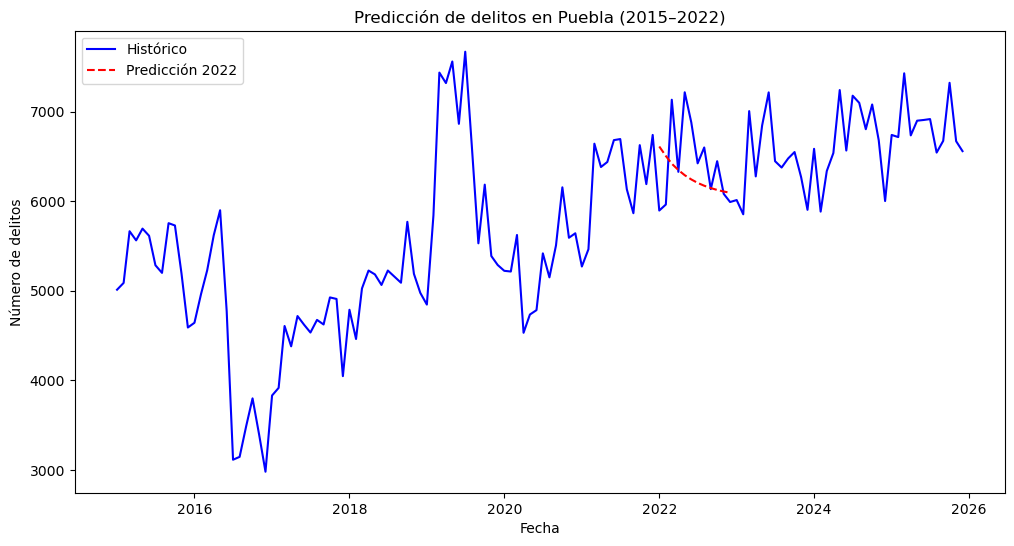

In [40]:
plt.figure(figsize=(12,6))

#Histórico
plt.plot(df_ts, label='Histórico', color='blue')

#Predicción
plt.plot(df_forecast, label='Predicción 2022', linestyle='--', color='red')

plt.title('Predicción de delitos en Puebla (2015–2022)')
plt.xlabel('Fecha')
plt.ylabel('Número de delitos')
plt.legend()

plt.show()

In [41]:
#CLUSTERING - PELIGROSIDAD 2021

df_2021 = df_norm_py[df_norm_py['Año'] == 2021]

#Agrupar por estado
df_estado = (
    df_2021
    .groupby('Entidad')['Delitos']
    .sum()
    .reset_index()
)

df_estado.head()

,Entidad,Delitos
0,Aguascalientes,35645
1,Baja California,98090
2,Baja California Sur,18677
3,Campeche,5611
4,Chiapas,17130


In [42]:
#Normalización
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_estado['Delitos_norm'] = scaler.fit_transform(
    df_estado[['Delitos']]
)

In [43]:
#Importación de librerías a utilizar
from sklearn.cluster import KMeans

c:\Users\Nefi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Nefi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Nefi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Nefi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

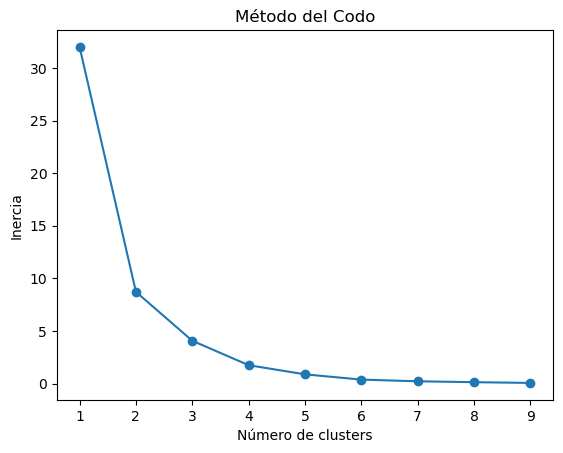

In [44]:
inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_estado[['Delitos_norm']])
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.show()

In [45]:
kmeans = KMeans(n_clusters=3, random_state=42)

df_estado['Cluster'] = kmeans.fit_predict(
    df_estado[['Delitos_norm']]
)

c:\Users\Nefi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


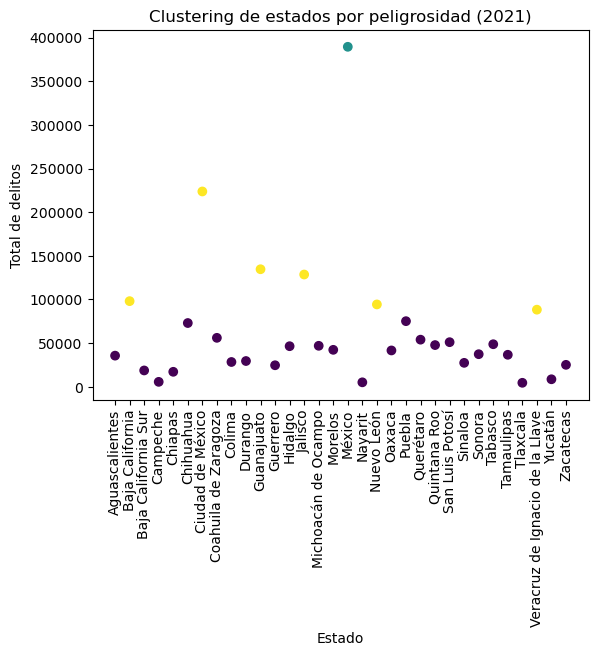

In [46]:
plt.figure()

plt.scatter(
    df_estado['Entidad'],
    df_estado['Delitos'],
    c=df_estado['Cluster']
)

plt.xticks(rotation=90)
plt.title('Clustering de estados por peligrosidad (2021)')
plt.xlabel('Estado')
plt.ylabel('Total de delitos')

plt.show()

In [47]:
df_estado.sort_values('Delitos', ascending=False)

,Entidad,Delitos,Delitos_norm,Cluster
16,México,389492,4.431318,1
6,Ciudad de México,223742,2.175573,2
10,Guanajuato,134626,0.962765,2
13,Jalisco,128588,0.880592,2
1,Baja California,98090,0.465534,2
18,Nuevo León,94321,0.414241,2
29,Veracruz de Ignacio de la Llave,88306,0.332381,2
20,Puebla,75141,0.153214,0
5,Chihuahua,73006,0.124158,0
7,Coahuila de Zaragoza,56045,-0.106669,0
